In [27]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree


data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB
None


In [29]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [30]:
X = df.drop('class', axis=1)
y = df['class']

categorical_features = X.select_dtypes(include=['category', 'object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print("Категориальные признаки:", categorical_features)
print("Числовые признаки:", numerical_features)

X_encoded = pd.get_dummies(X, columns=categorical_features)

y_encoded = y.apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

Категориальные признаки: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')
Числовые признаки: Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


### в scikit-learn нет чистого ID3, но DecisionTreeClassifier с criterion='gini' похож 

In [31]:
model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

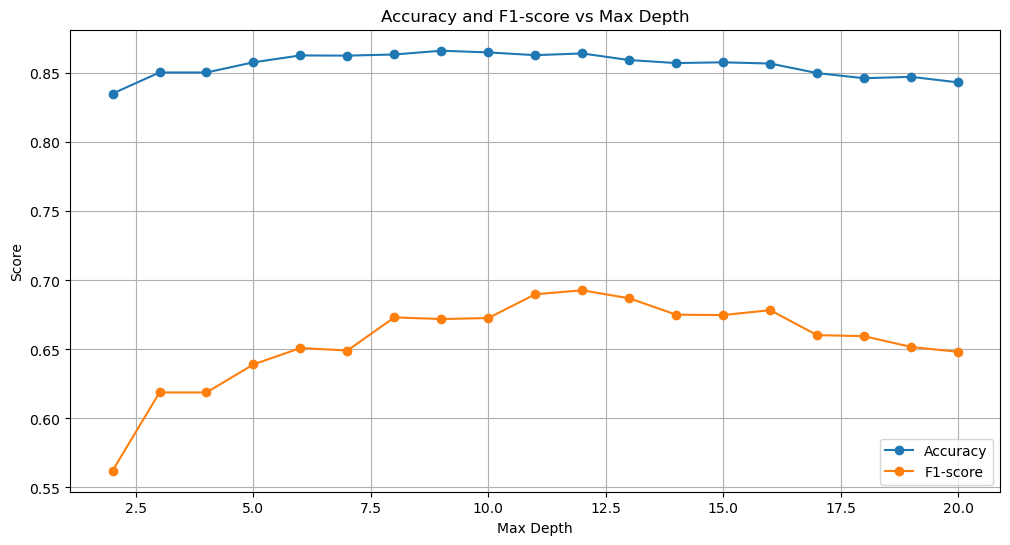

In [32]:
max_depths = range(2, 21)
accuracies = []
f1_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

# Построение графиков
plt.figure(figsize=(12, 6))
plt.plot(max_depths, accuracies, label='Accuracy', marker='o')
plt.plot(max_depths, f1_scores, label='F1-score', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Accuracy and F1-score vs Max Depth')
plt.legend()
plt.grid()
plt.show()

Оптимальная глубина: 12
Матрица ошибок:
[[10425   808]
 [ 1179  2241]]


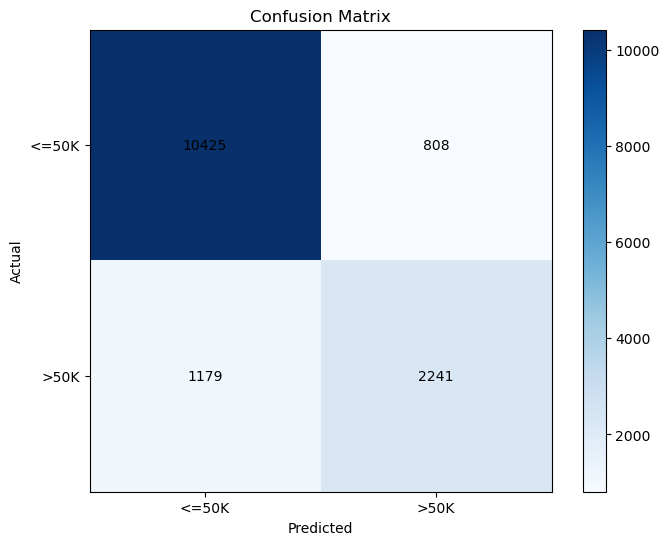

In [33]:

optimal_depth = max_depths[f1_scores.index(max(f1_scores))]
print("Оптимальная глубина:", optimal_depth)

model = DecisionTreeClassifier(criterion='gini', max_depth=optimal_depth, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['<=50K', '>50K'])
plt.yticks([0, 1], ['<=50K', '>50K'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center')
plt.show()

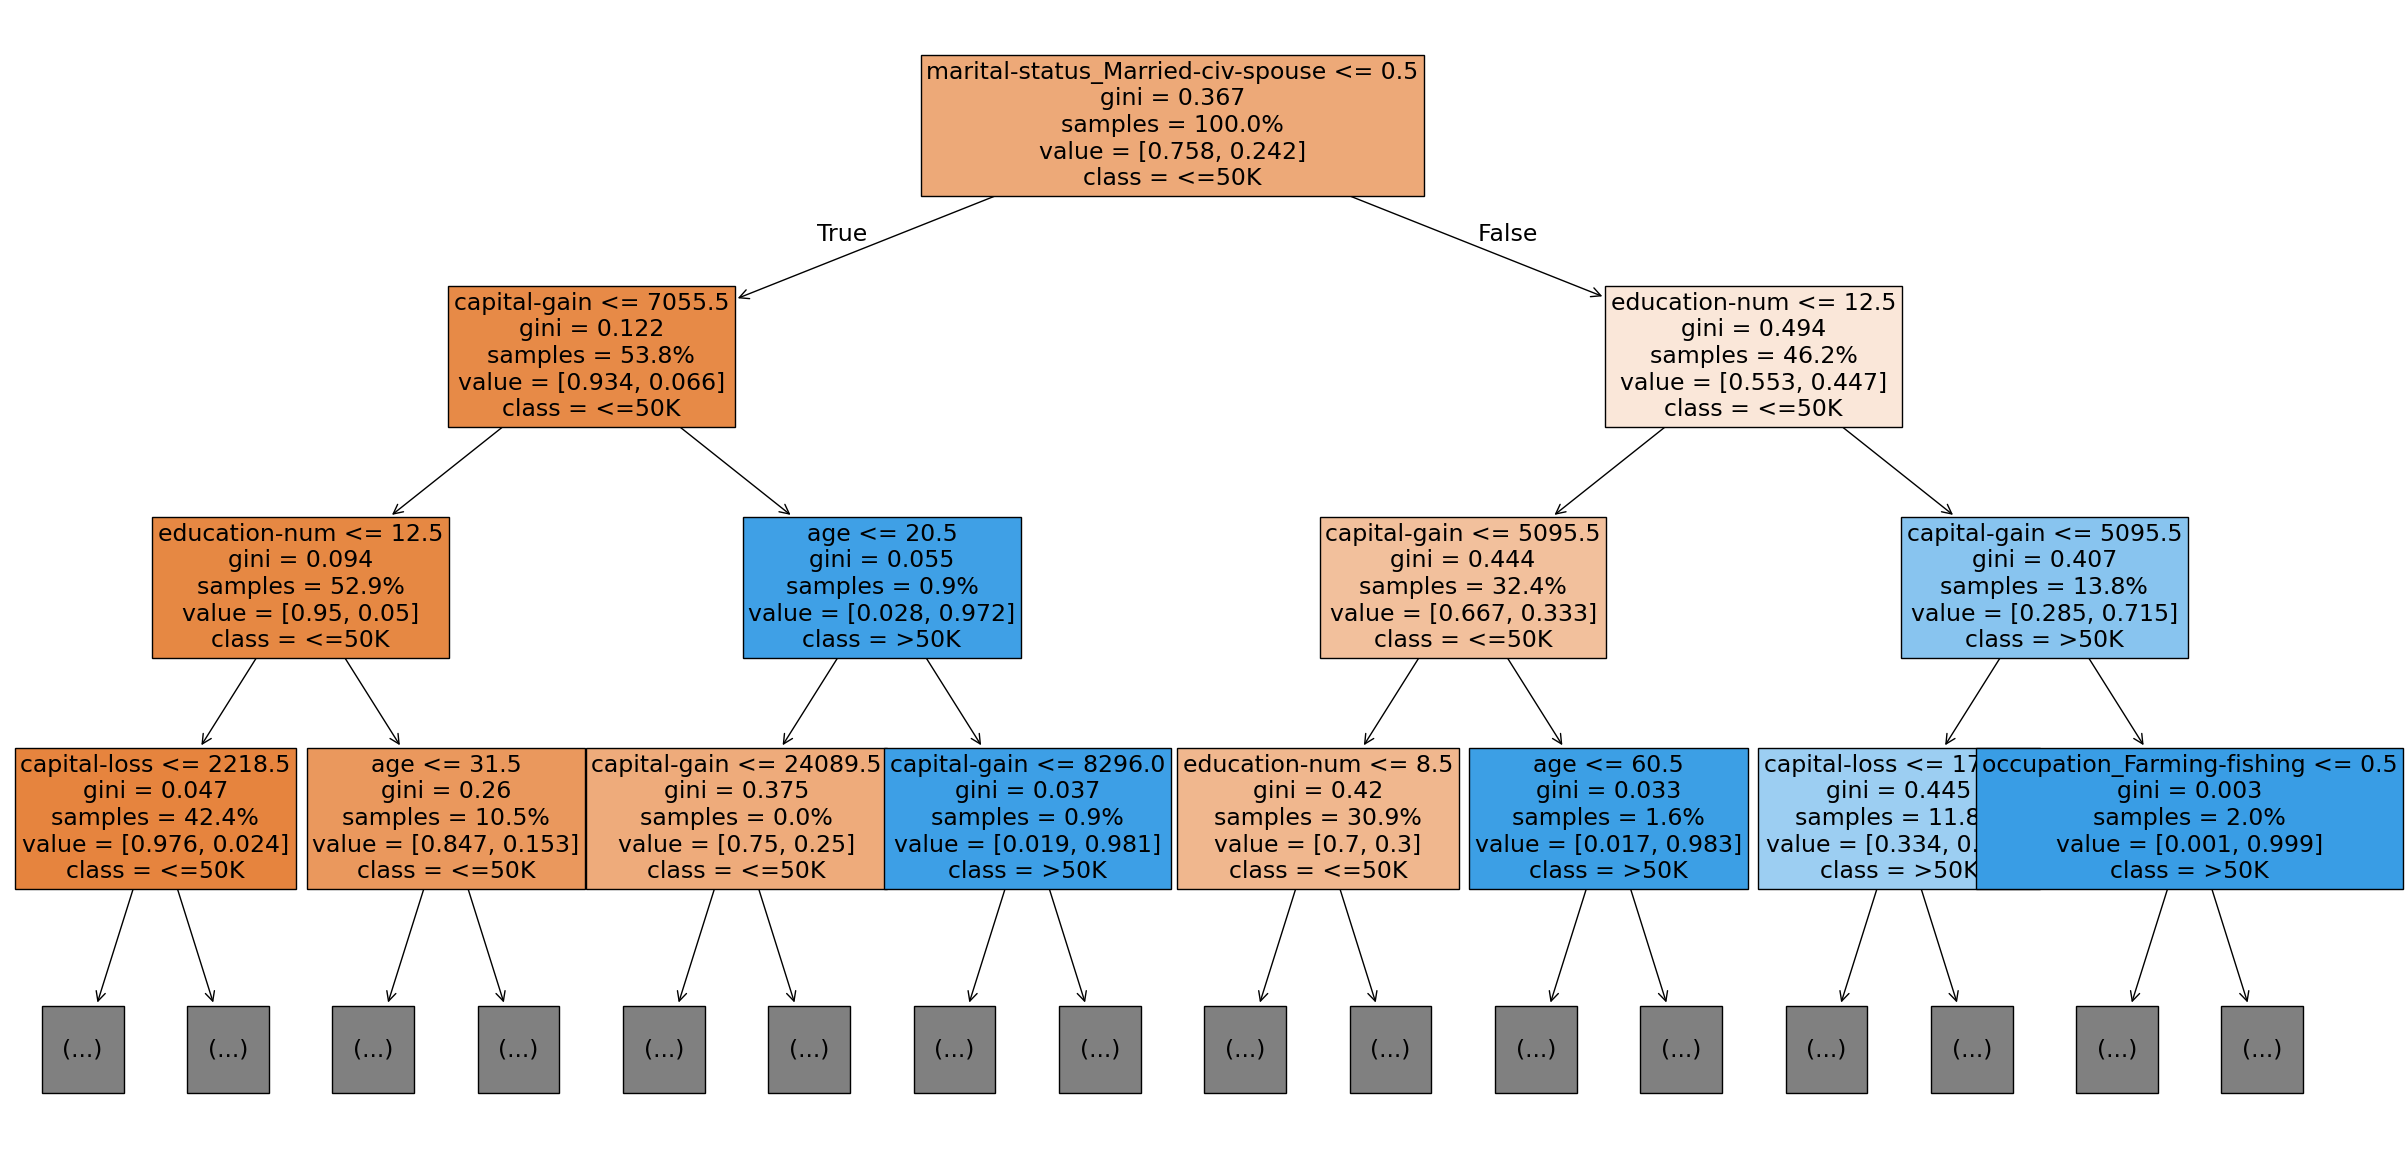

In [34]:
plt.figure(figsize=(30, 15))
tree.plot_tree(
    model,
    filled=True,
    feature_names=X_encoded.columns,
    class_names=['<=50K', '>50K'],
    max_depth=3,
    fontsize=17, 
    proportion=True
)
plt.show()